In [ ]:
# Gowtham S - 24BAD028

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Part A

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", x_test.shape)
print("Testing labels :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


#### Display Sample Images

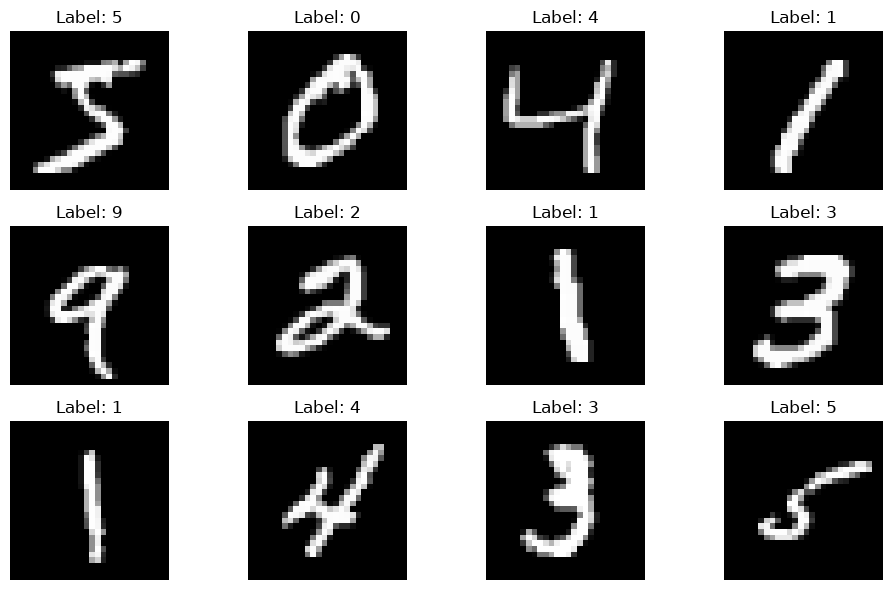

In [4]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Normalize the Images

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#### Reshape Images

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)


#### Create Validation Dataset

In [7]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training   :", x_train.shape)
print("Validation :", x_val.shape)
print("Testing    :", x_test.shape)

Training   : (55000, 28, 28, 1)
Validation : (5000, 28, 28, 1)
Testing    : (10000, 28, 28, 1)


### Part B - CNN Model Implementation

#### Build CNN

In [8]:
model = Sequential([

    # Convolution Layer 1
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    # Max Pooling 1
    MaxPooling2D((2, 2)),

    # Convolution Layer 2
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling 2
    MaxPooling2D((2, 2)),

    # Convert feature maps into vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Reduce overfitting
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

model.summary()

/run/media/nishanth/NP/KCT/24ADI006L-DL-24BAD405/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786298982.678299   21969 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786298982.679468   22275 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786298982.706193   21969 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are i

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Part C - Training and Evaluation

#### Train CNN

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.9244 - loss: 0.2431 - val_accuracy: 0.9872 - val_loss: 0.0464
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.9760 - loss: 0.0811 - val_accuracy: 0.9894 - val_loss: 0.0362
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9813 - loss: 0.0622 - val_accuracy: 0.9922 - val_loss: 0.0313
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9854 - loss: 0.0482 - val_accuracy: 0.9908 - val_loss: 0.0351
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9868 - loss: 0.0417 - val_accuracy: 0.9924 - val_loss: 0.0297
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9881 - loss: 0.0375 - val_accuracy: 0.9916 - val_loss: 0.0297
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9898 - loss: 0.0318 - val_accuracy: 0.9926 - val_loss: 0.0330
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9911 - loss: 0.0274 - 

#### Test the Model

In [11]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Testing Loss     :", test_loss)
print("Testing Accuracy :", test_accuracy)

Testing Loss     : 0.027557440102100372
Testing Accuracy : 0.9911999702453613


#### Display Performance

In [12]:
print("Final Training Accuracy   :",
      history.history['accuracy'][-1])

print("Final Validation Accuracy :",
      history.history['val_accuracy'][-1])

print("Final Training Loss       :",
      history.history['loss'][-1])

print("Final Validation Loss     :",
      history.history['val_loss'][-1])

print("Testing Accuracy          :",
      test_accuracy)

Final Training Accuracy   : 0.9929090738296509
Final Validation Accuracy : 0.991599977016449
Final Training Loss       : 0.02145378105342388
Final Validation Loss     : 0.032021574676036835
Testing Accuracy          : 0.9911999702453613


#### Accuracy vs Epoch

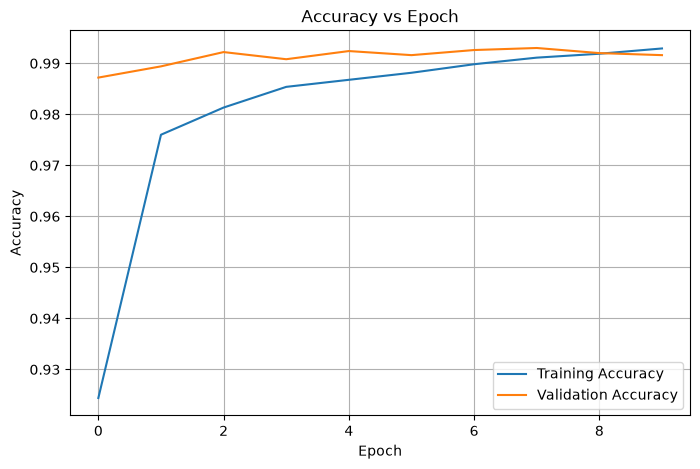

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

#### Loss vs Epoch

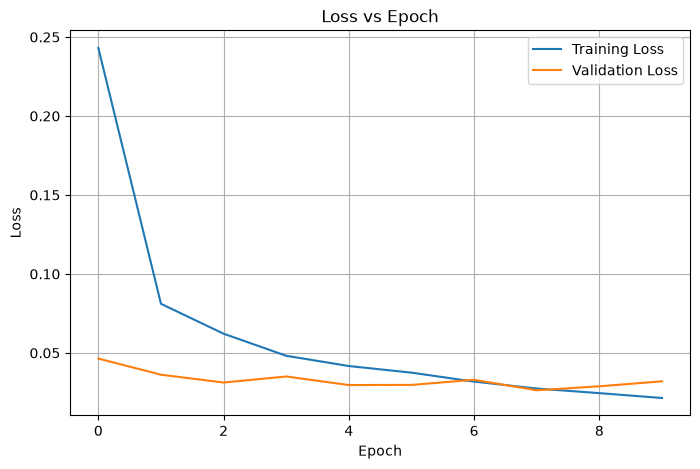

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Part D - Performance Analysis

#### Generate Predictions

In [15]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = y_test

print("Predicted:", predicted_classes[:20])
print("Actual   :", actual_classes[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
Actual   : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


#### Confusion Matrix

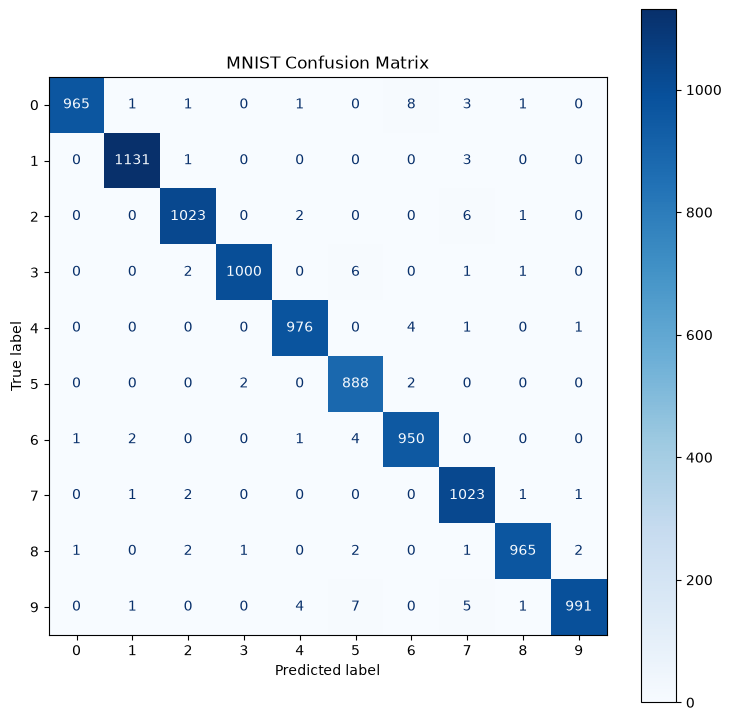

In [ ]:
cm = confusion_matrix(
    actual_classes,
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10))

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    cmap='Blues'
)

plt.title("MNIST Confusion Matrix")
plt.show()

#### Sample Predictions

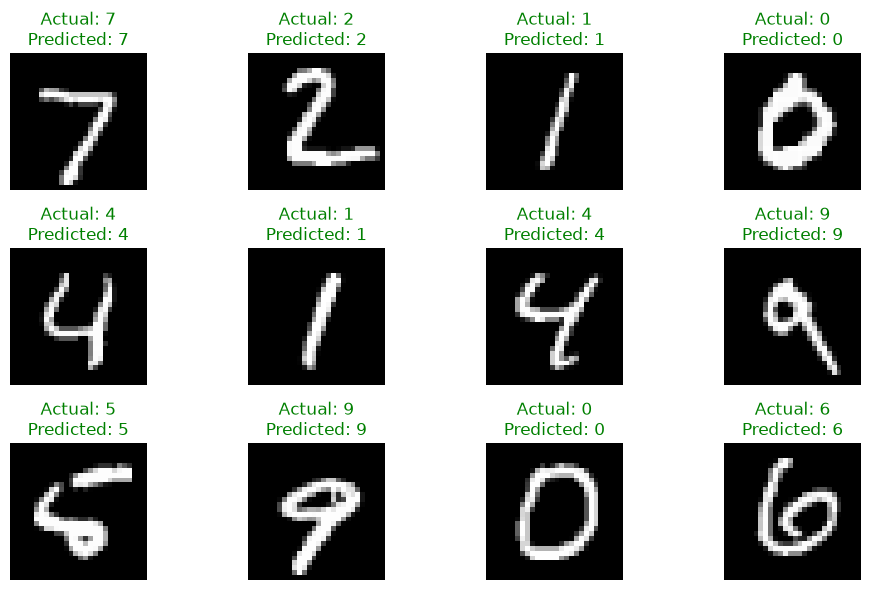

In [17]:
plt.figure(figsize=(10, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap='gray'
    )

    actual = actual_classes[i]
    predicted = predicted_classes[i]

    if actual == predicted:
        color = 'green'
    else:
        color = 'red'

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=color
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

#### Misclassified Calculation

In [18]:
misclassified_indices = np.where(
    predicted_classes != actual_classes
)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices)
)

Number of misclassified images: 88


#### Misclassified Images

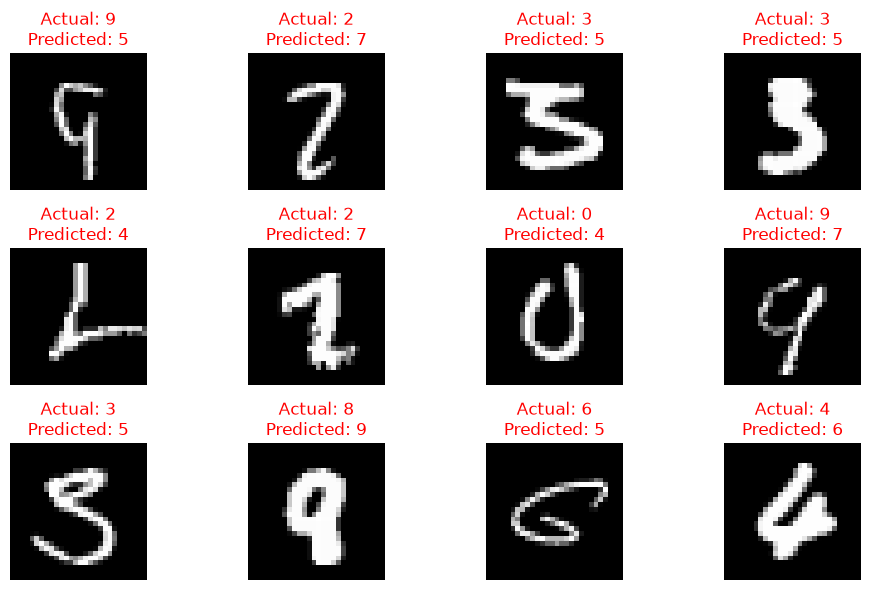

In [19]:
plt.figure(figsize=(10, 6))

for i, index in enumerate(
    misclassified_indices[:12]
):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test[index].reshape(28, 28),
        cmap='gray'
    )

    actual = actual_classes[index]
    predicted = predicted_classes[index]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color='red'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()